# 10 — K-Nearest Neighbors Regressor (Regression Track)
**23CSE301 Machine Learning — Capstone, Review 1**

**Dataset:** UK Used Cars (`used_cars.csv`) **Target:** `price` (£)

| Block | Rubric section |
|---|---|
| 1 | Section A — Dataset & EDA |
| 2 | Section B — Preprocessing & Feature Engineering |
| 3 | Section C — Regression Track (K-Nearest Neighbors Regressor) |

KNN Regression has no real training step: it **stores** the training cars and, for a new car, finds the **k most similar** cars (smallest distance) and predicts the **average of their prices** (optionally weighted by closeness). **k** controls smoothness (small k = noisy, large k = over-smoothed). Because it relies on distances, **feature scaling is critical**. This notebook also contains the **final comparison of all 10 regression models**.

---
# BLOCK 1 — Dataset & EDA (Section A)

In [1]:
# ============================================================
# BLOCK 1 : DATASET & EDA
# ============================================================

# ---- 1.0 Imports & global settings ----
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42                      # fixed seed for reproducibility (guideline 7.1)
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")   # colour-blind-friendly palette (guideline 7.3)
pd.set_option("display.max_columns", 50)

DATA_PATH = "../data/used_cars.csv"    # change if your file is somewhere else
TARGET = "price"

## A1 — Dataset loading & audit
Shape, dtypes, missing values, duplicates and target distribution.

In [2]:
# ---- 1.1 Load the dataset ----
df = pd.read_csv(DATA_PATH)

# 'Unnamed: 0' is just an old row index saved into the CSV -> not a real feature
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Some text columns have stray spaces (e.g. ' T-Roc') -> strip them
for col in df.select_dtypes(include="object").columns.union(df.select_dtypes(include="string").columns):
    df[col] = df[col].astype(str).str.strip()

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (99187, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0,VW
1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0,VW
2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0,VW
3,T-Roc,2019,33492,Automatic,4825,Petrol,145,32.5,2.0,VW
4,T-Roc,2019,22900,Semi-Auto,6500,Petrol,150,39.8,1.5,VW


In [3]:
# ---- 1.2 Data types & basic info ----
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isnull().sum(),
    "missing_%": (df.isnull().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
print("Duplicate rows:", df.duplicated().sum())
audit

Duplicate rows: 1475


,dtype,missing_count,missing_%,n_unique
model,str,0,0.0,195
year,int64,0,0.0,27
price,int64,0,0.0,13236
transmission,str,0,0.0,4
mileage,int64,0,0.0,42214
fuelType,str,0,0.0,5
tax,int64,0,0.0,48
mpg,float64,0,0.0,208
engineSize,float64,0,0.0,40
Make,str,0,0.0,9


In [4]:
# ---- 1.3 Statistical summary of numeric columns ----
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,99187.0,2017.087723,2.123934,1970.0,2016.0,2017.0,2019.0,2060.0
price,99187.0,16805.347656,9866.773417,450.0,9999.0,14495.0,20870.0,159999.0
mileage,99187.0,23058.914213,21148.523721,1.0,7425.0,17460.0,32339.0,323000.0
tax,99187.0,120.299838,63.150926,0.0,125.0,145.0,145.0,580.0
mpg,99187.0,55.166825,16.138522,0.3,47.1,54.3,62.8,470.8
engineSize,99187.0,1.663280,0.557646,0.0,1.2,1.6,2.0,6.6


In [5]:
# ---- 1.4 Target distribution summary ----
print(df[TARGET].describe())
print("\nSkewness of price:", round(df[TARGET].skew(), 3))

# Category counts (the 'class distribution' view for the categorical columns)
for col in ["Make", "transmission", "fuelType"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

count     99187.000000
mean      16805.347656
std        9866.773417
min         450.000000
25%        9999.000000
50%       14495.000000
75%       20870.000000
max      159999.000000
Name: price, dtype: float64

Skewness of price: 2.347

--- Make ---
Make
ford        17965
VW          15157
vauxhall    13632
merc        13119
BMW         10781
Audi        10668
toyota       6738
skoda        6267
hyundi       4860
Name: count, dtype: int64

--- transmission ---
transmission
Manual       56445
Semi-Auto    22677
Automatic    20056
Other            9
Name: count, dtype: int64

--- fuelType ---
fuelType
Petrol      54928
Diesel      40928
Hybrid       3078
Other         247
Electric        6
Name: count, dtype: int64


## A2 — EDA visualisations

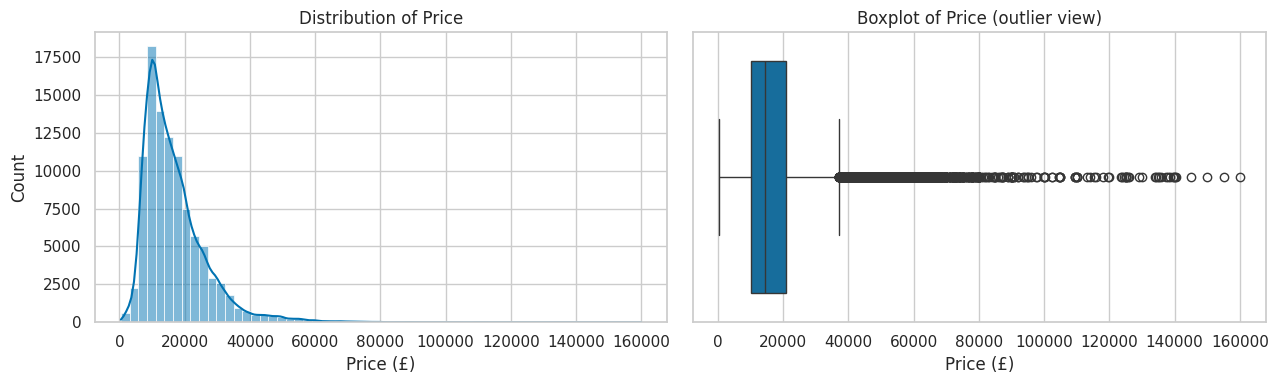

In [6]:
# ---- 1.5 Target distribution (price) ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df[TARGET], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Price")
axes[0].set_xlabel("Price (£)"); axes[0].set_ylabel("Count")

sns.boxplot(x=df[TARGET], ax=axes[1])
axes[1].set_title("Boxplot of Price (outlier view)")
axes[1].set_xlabel("Price (£)")
plt.tight_layout(); plt.show()

**📝 What this shows:** Most cars cost between £10,000 and £21,000, but a few cost up to £160,000, so the price chart has a long tail on the right.

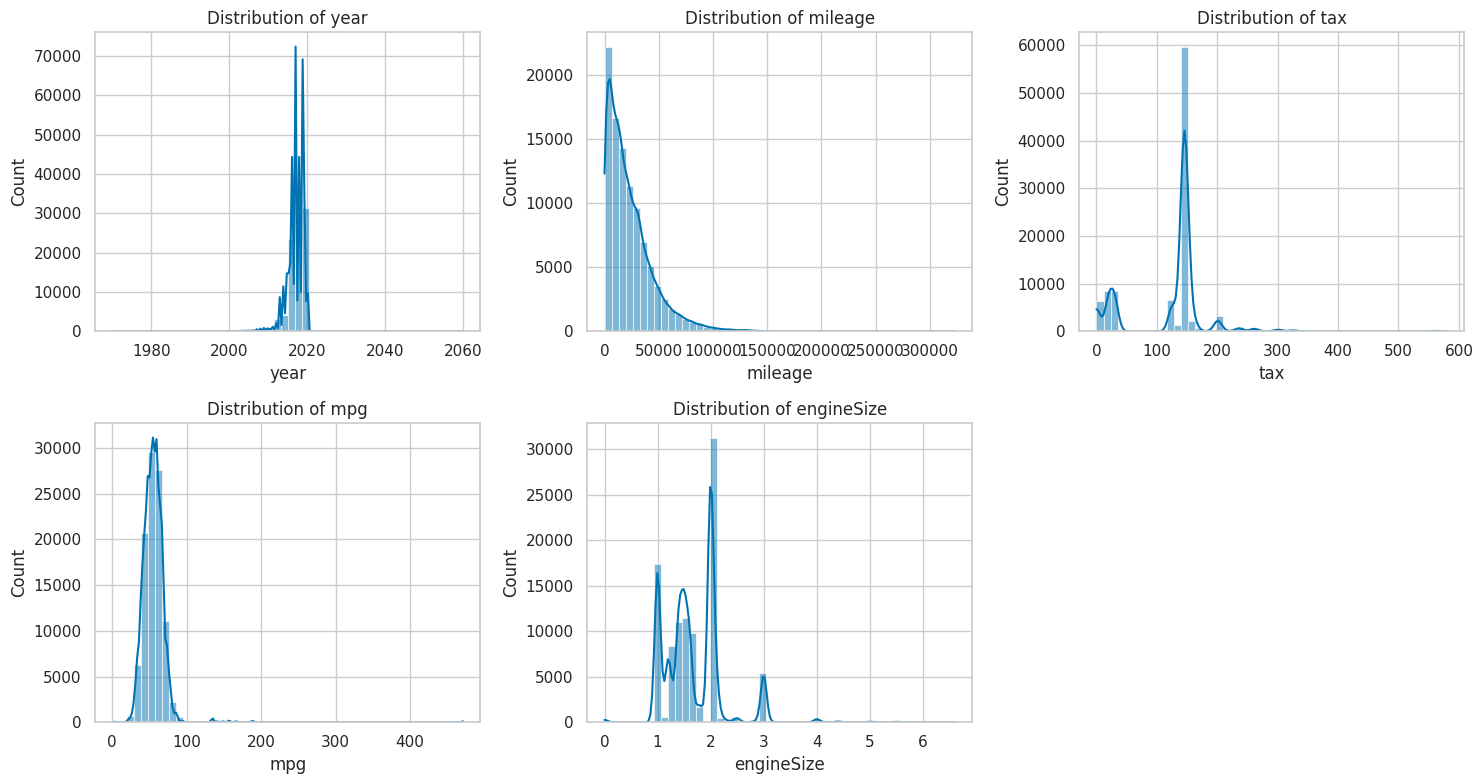

In [7]:
# ---- 1.6 Distribution plot for EACH numeric feature ----
num_features = ["year", "mileage", "tax", "mpg", "engineSize"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_features):
    sns.histplot(df[col], bins=50, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col); ax.set_ylabel("Count")
axes.flat[-1].set_visible(False)       # hide the unused 6th subplot
plt.tight_layout(); plt.show()

**📝 What this shows:** Most cars are recent and low-mileage, and there are a few impossible values: one car dated 2060, some with 470 mpg, and 266 with a 0-litre engine.

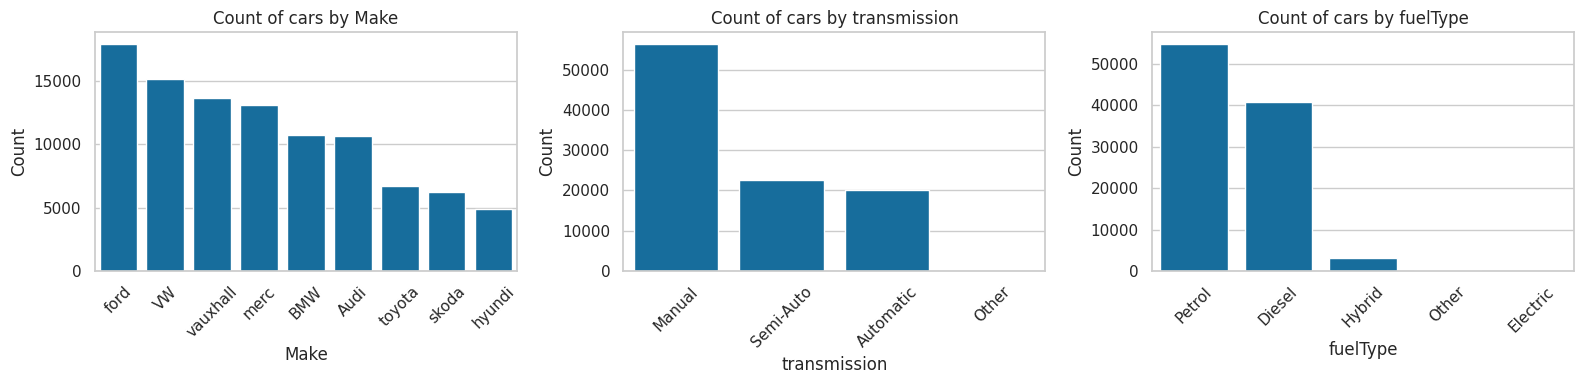

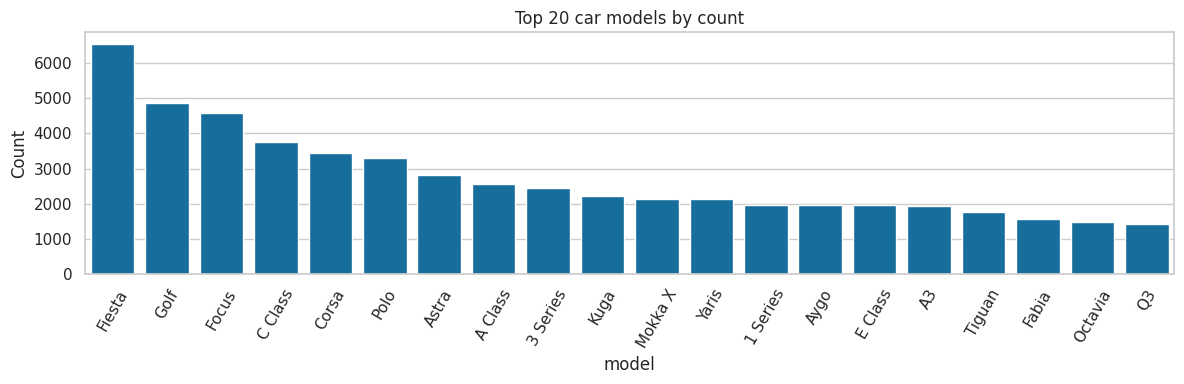

In [8]:
# ---- 1.7 Distribution plot for EACH categorical feature ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Make", "transmission", "fuelType"]):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(f"Count of cars by {col}")
    ax.set_xlabel(col); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

# 'model' has ~195 values -> show only the top 20
plt.figure(figsize=(12, 4))
top_models = df["model"].value_counts().head(20)
sns.barplot(x=top_models.index, y=top_models.values)
plt.title("Top 20 car models by count")
plt.xlabel("model"); plt.ylabel("Count"); plt.xticks(rotation=60)
plt.tight_layout(); plt.show()

**📝 What this shows:** Ford and VW are the most common brands, most cars are manual, and petrol and diesel cover nearly everything — electric cars are almost absent (only 6).

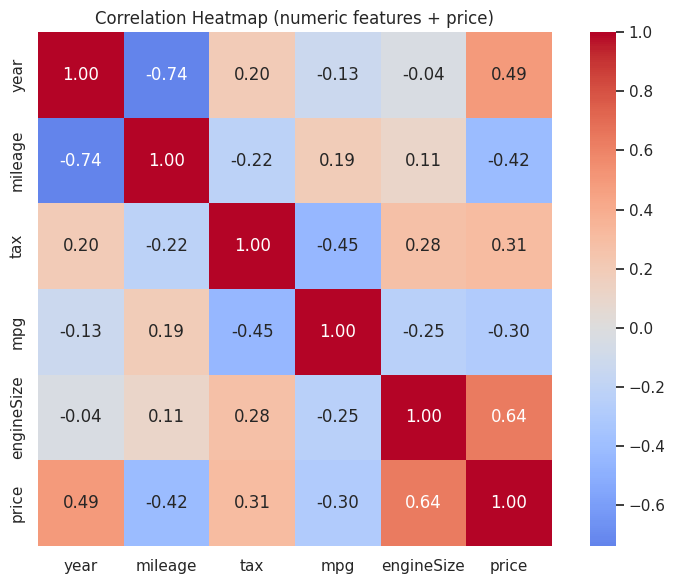

In [9]:
# ---- 1.8 Correlation heatmap (numeric columns incl. target) ----
plt.figure(figsize=(8, 6))
corr = df[num_features + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (numeric features + price)")
plt.tight_layout(); plt.show()

**📝 What this shows:** Price goes up with engine size (0.65) and newer year (0.49), and goes down as mileage rises (−0.42).

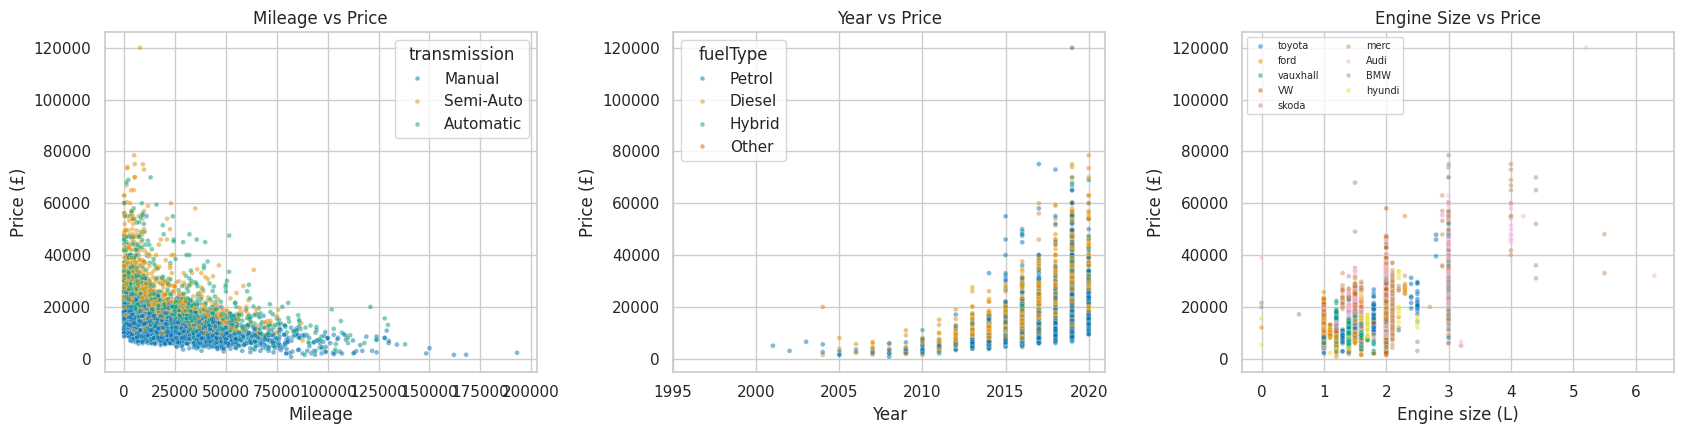

In [10]:
# ---- 1.9 Scatter plots: feature vs target ----
sample = df.sample(5000, random_state=RANDOM_STATE)   # sample so the plot is readable

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.scatterplot(data=sample, x="mileage", y=TARGET, hue="transmission", alpha=0.5, s=12, ax=axes[0])
axes[0].set_title("Mileage vs Price"); axes[0].set_xlabel("Mileage"); axes[0].set_ylabel("Price (£)")

sns.scatterplot(data=sample, x="year", y=TARGET, hue="fuelType", alpha=0.5, s=12, ax=axes[1])
axes[1].set_title("Year vs Price"); axes[1].set_xlabel("Year"); axes[1].set_ylabel("Price (£)")
axes[1].set_xlim(1995, 2021)

sns.scatterplot(data=sample, x="engineSize", y=TARGET, hue="Make", alpha=0.5, s=12, ax=axes[2])
axes[2].set_title("Engine Size vs Price"); axes[2].set_xlabel("Engine size (L)"); axes[2].set_ylabel("Price (£)")
axes[2].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

**📝 What this shows:** The lines are curved, not straight: price drops fast in the first few years and miles, then flattens out.

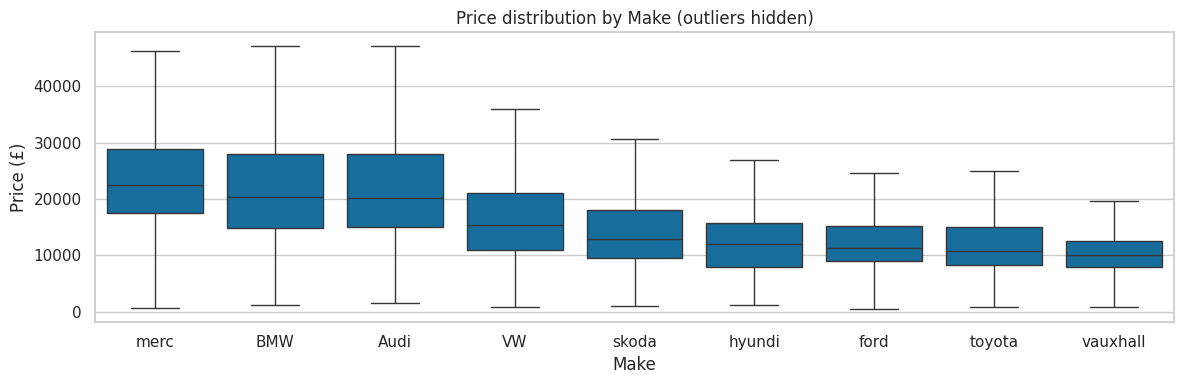

In [11]:
# ---- 1.10 Price by brand (categorical feature vs target) ----
plt.figure(figsize=(12, 4))
order = df.groupby("Make")[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Make", y=TARGET, order=order, showfliers=False)
plt.title("Price distribution by Make (outliers hidden)")
plt.xlabel("Make"); plt.ylabel("Price (£)")
plt.tight_layout(); plt.show()

**📝 What this shows:** Mercedes, BMW and Audi cost about twice as much as Vauxhall and Toyota, so the brand matters a lot.

---
# BLOCK 2 — Preprocessing & Feature Engineering (Section B)

In [12]:
# ============================================================
# BLOCK 2 : PREPROCESSING & FEATURE ENGINEERING
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# ---- 2.1 Remove duplicate rows ----
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {before - len(df)}  ->  rows now: {len(df)}")

# ---- 2.2 Remove impossible / invalid rows ----
# year > 2020 is impossible for this dataset (data was collected in 2020)
invalid_year = df["year"] > 2020
print("Rows with invalid year (>2020):", invalid_year.sum())
df = df[~invalid_year].reset_index(drop=True)

# ---- 2.3 Hidden missing values ----
# The CSV has no NaNs, but engineSize = 0 is not a real engine size for petrol/diesel cars,
# so we treat it as 'missing' and impute it later (after the split, using train data only).
hidden_missing = (df["engineSize"] == 0) & (df["fuelType"] != "Electric")
print("engineSize == 0 (treated as missing):", hidden_missing.sum())
df.loc[hidden_missing, "engineSize"] = np.nan
print("\nMissing values now:\n", df.isnull().sum()[df.isnull().sum() > 0])

Duplicates removed: 1475  ->  rows now: 97712
Rows with invalid year (>2020): 1
engineSize == 0 (treated as missing): 266

Missing values now:
 engineSize    266
dtype: int64


**Missing-value strategy:** `engineSize` NaNs are filled with the **median engine size of the same car model**
(computed on the training set only), falling back to the overall training median. The same model almost always
has a similar engine, and the median is robust to outliers.

## B3 — Feature engineering

In [13]:
# ---- 2.4 Engineered features ----
REF_YEAR = 2020                                            # year the data was collected
df["car_age"] = REF_YEAR - df["year"]                      # age of the car in years
df["mileage_per_year"] = df["mileage"] / (df["car_age"] + 1)   # +1 avoids divide-by-zero for 2020 cars

df[["year", "car_age", "mileage", "mileage_per_year", TARGET]].corr()[TARGET]

year                0.492556
car_age            -0.492556
mileage            -0.417987
mileage_per_year   -0.294263
price               1.000000
Name: price, dtype: float64

**Why these features may help:**
- `car_age` — depreciation depends on how old a car is; age is easier to interpret than the raw year.
- `mileage_per_year` — separates a *heavily used* young car from a *lightly used* old car, which raw
  mileage alone cannot do. Usage intensity affects wear and resale value.

## B2 — Stratified train/test split, encoding & scaling

In [14]:
# ---- 2.5 Separate features and target ----
cat_cols = ["model", "transmission", "fuelType", "Make"]
num_cols = ["mileage", "tax", "mpg", "engineSize", "car_age", "mileage_per_year"]
# ('year' is dropped because car_age carries the same information)

X = df[cat_cols + num_cols]
y = df[TARGET]

# ---- 2.6 Stratified 80:20 split ----
# price is continuous, so we stratify on price *bins* (quintiles)
# -> train and test get the same spread of cheap / mid / expensive cars
price_bins = pd.qcut(y, q=5, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=price_bins
)
X_train, X_test = X_train.copy(), X_test.copy()
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Mean price  train: %.0f | test: %.0f" % (y_train.mean(), y_test.mean()))

Train: (78168, 10)  Test: (19543, 10)
Mean price  train: 16778 | test: 16756


In [15]:
# ---- 2.7 Impute engineSize (statistics from TRAIN only) ----
model_median = X_train.groupby("model")["engineSize"].median()
global_median = X_train["engineSize"].median()

for part in (X_train, X_test):
    part["engineSize"] = part["engineSize"].fillna(part["model"].map(model_median)).fillna(global_median)

print("Missing after imputation -> train:", X_train.isnull().sum().sum(), "| test:", X_test.isnull().sum().sum())

Missing after imputation -> train: 0 | test: 0


In [16]:
# ---- 2.8 Outlier check (IQR) & treatment (capping) ----
outlier_report = {}
caps = {}
for col in ["mileage", "tax", "mpg", "engineSize", "mileage_per_year"]:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_report[col] = int(((X_train[col] < low) | (X_train[col] > high)).sum())
    # Cap at the 1st / 99th percentile of TRAIN (keeps rows, limits extreme values)
    caps[col] = (X_train[col].quantile(0.01), X_train[col].quantile(0.99))

print("IQR outliers in train set:")
print(pd.Series(outlier_report))

for col, (lo, hi) in caps.items():
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col] = X_test[col].clip(lo, hi)     # same train-derived limits applied to test

IQR outliers in train set:
mileage              3075
tax                 22880
mpg                   712
engineSize            548
mileage_per_year     1773
dtype: int64


**Outlier strategy:** values are **capped** at the train-set 1st/99th percentiles instead of deleted — rows are kept,
but impossible values (e.g. mpg = 470) can no longer distort the model. The target `price` is **not** capped,
because expensive cars are genuine.

In [17]:
# ---- 2.9 Encoding + scaling (fitted on TRAIN only -> no data leakage) ----
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),                                   # scale numeric features
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),  # one-hot encode categoricals
])

X_train_p = preprocessor.fit_transform(X_train)    # FIT + transform on train
X_test_p = preprocessor.transform(X_test)          # ONLY transform on test

feature_names = preprocessor.get_feature_names_out()
print("Processed train shape:", X_train_p.shape)
print("Processed test shape :", X_test_p.shape)

Processed train shape: (78168, 218)
Processed test shape : (19543, 218)


---
# BLOCK 3 — Regression Track: K-Nearest Neighbors Regressor (Section C)

In [18]:
# ============================================================
# BLOCK 3 : REGRESSION — K-NEAREST NEIGHBORS REGRESSOR
# ============================================================
import time
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def regression_metrics(y_true, y_hat):
    # returns R2, RMSE and MAE as a dict
    return {
        "R2": r2_score(y_true, y_hat),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_hat)),
        "MAE": mean_absolute_error(y_true, y_hat),
    }

def stratified_subsample(n, seed=RANDOM_STATE):
    # row positions of a price-stratified subsample of the training set
    idx, _ = train_test_split(np.arange(len(X_train_p)), train_size=n, random_state=seed,
                              stratify=pd.qcut(y_train, q=5, labels=False))
    return idx

# ---- 3.1 'Train' a default KNN (k=5, uniform weights, Euclidean distance) ----
# fit() only stores the data -> it is instant; the work happens at prediction time
start = time.time()
knn_default = KNeighborsRegressor(n_jobs=-1)
knn_default.fit(X_train_p, y_train)
print(f"Fit time: {time.time() - start:.2f} s")

# ---- 3.2 Predictions ----
start = time.time()
y_pred_default = knn_default.predict(X_test_p)
print(f"Prediction time for {len(X_test_p)} test cars: {time.time() - start:.1f} s")
print("First 5 predictions:", np.round(y_pred_default[:5], 0))
print("First 5 actual     :", y_test.values[:5])

default_scores = regression_metrics(y_test, y_pred_default)
pd.DataFrame([default_scores], index=["KNN default (k=5, uniform, euclidean)"]).round(4)

Fit time: 0.02 s


Prediction time for 19543 test cars: 16.0 s
First 5 predictions: [14651. 22237.  8532. 12038. 20553.]
First 5 actual     : [14995 26995  8198 11499 19465]


,R2,RMSE,MAE
"KNN default (k=5, uniform, euclidean)",0.9438,2352.6967,1310.0864


**📝 What this shows:** Training takes 0.02 seconds but predicting takes 16 seconds, because all the work happens when you ask for a prediction.

## Impact of scaling

Standard deviation of the raw numeric features:
mileage             20096.5
tax                    59.9
mpg                    11.4
engineSize              0.5
car_age                 2.1
mileage_per_year     3262.6
dtype: float64


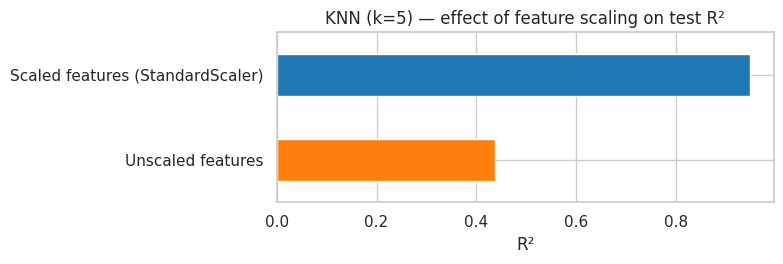

,R2,RMSE,MAE
setup,,,
Unscaled features,0.4365,7607.0944,5184.3892
Scaled features (StandardScaler),0.9485,2298.5450,1316.7237


In [19]:
# ---- 3.3 Same KNN on UNSCALED vs SCALED numeric features ----
unscaled_prep = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
X_train_raw = unscaled_prep.fit_transform(X_train)     # fitted on train only
X_test_raw = unscaled_prep.transform(X_test)
check = slice(0, 5000)                                  # 5,000 test rows for a quick check

scale_rows = []
for name, (Xtr, Xte) in {"Unscaled features": (X_train_raw, X_test_raw),
                         "Scaled features (StandardScaler)": (X_train_p, X_test_p)}.items():
    m = KNeighborsRegressor(n_jobs=-1).fit(Xtr, y_train)
    scale_rows.append({"setup": name, **regression_metrics(y_test.values[check], m.predict(Xte[check]))})
scale_df = pd.DataFrame(scale_rows).set_index("setup")

# what dominates the distance without scaling? -> compare feature ranges
print("Standard deviation of the raw numeric features:")
print(X_train[num_cols].std().round(1))

scale_df["R2"].plot(kind="barh", figsize=(8, 2.8), color=["tab:orange", "tab:blue"])
plt.title("KNN (k=5) — effect of feature scaling on test R²")
plt.xlabel("R²"); plt.ylabel("")
plt.tight_layout(); plt.show()
scale_df.round(4)

**📝 What this shows:** Mileage takes over the calculation when nothing is scaled, so the score drops from 0.95 to 0.44.

## C3 — Effect of k (full training set)

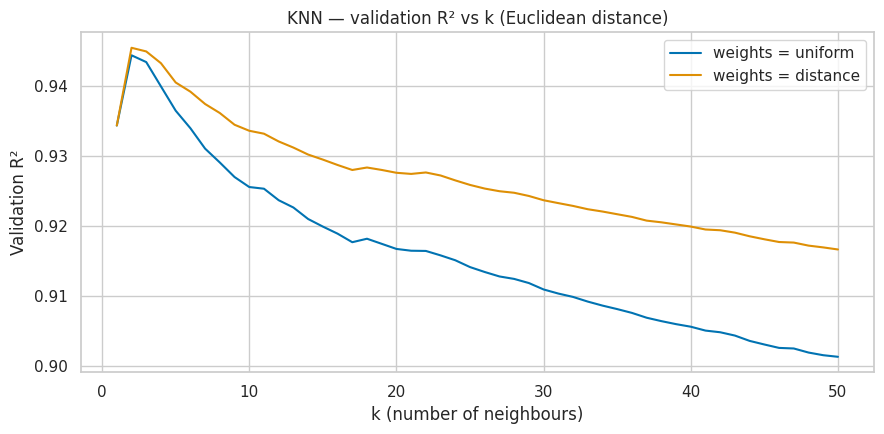

Best k (uniform) : 2 -> R2 = 0.9445
Best k (distance): 2 -> R2 = 0.9455


In [20]:
# ---- 3.4 Validation R2 for k = 1 ... 50 ----
# Trick: find the 50 nearest neighbours ONCE, then average the first k of them for every k.
# This gives the whole curve for the cost of a single prediction.
X_tr, X_val, y_tr, y_val = train_test_split(X_train_p, y_train.values, test_size=0.1, random_state=RANDOM_STATE,
                                            stratify=pd.qcut(y_train, q=5, labels=False))
nn = KNeighborsRegressor(n_neighbors=50, n_jobs=-1).fit(X_tr, y_tr)
dist, ind = nn.kneighbors(X_val)                 # shapes: (n_val, 50)
neigh_prices = y_tr[ind]

k_values = np.arange(1, 51)
r2_uniform, r2_distance = [], []
for k in k_values:
    r2_uniform.append(r2_score(y_val, neigh_prices[:, :k].mean(axis=1)))
    w = 1 / np.maximum(dist[:, :k], 1e-9)        # inverse-distance weights
    r2_distance.append(r2_score(y_val, (neigh_prices[:, :k] * w).sum(axis=1) / w.sum(axis=1)))

plt.figure(figsize=(9, 4.5))
plt.plot(k_values, r2_uniform, label="weights = uniform")
plt.plot(k_values, r2_distance, label="weights = distance")
plt.title("KNN — validation R² vs k (Euclidean distance)")
plt.xlabel("k (number of neighbours)"); plt.ylabel("Validation R²")
plt.legend(); plt.tight_layout(); plt.show()
print("Best k (uniform) :", k_values[np.argmax(r2_uniform)], "-> R2 = %.4f" % max(r2_uniform))
print("Best k (distance):", k_values[np.argmax(r2_distance)], "-> R2 = %.4f" % max(r2_distance))

**📝 What this shows:** Very small k copies single cars and very large k blurs everything, and weighting closer cars works better.

## C3 — Hyperparameter tuning (GridSearchCV)
Manhattan distance (`p=1`) cannot use fast matrix routines and is ~10× slower than Euclidean on this data,
so the grid search runs on a **stratified 10,000-row subsample** with 3-fold CV. The best settings are then applied
with the **full training set** as the neighbour pool.

In [21]:
# ---- 3.5 GridSearchCV over k, weights and distance metric ----
tune_idx = stratified_subsample(10000)
param_grid = {
    "n_neighbors": [3, 5, 7, 10, 15, 25],
    "weights": ["uniform", "distance"],
    "p": [1, 2],                     # 1 = Manhattan, 2 = Euclidean
}
grid = GridSearchCV(KNeighborsRegressor(n_jobs=-1), param_grid,
                    cv=KFold(3, shuffle=True, random_state=RANDOM_STATE),
                    scoring="r2", return_train_score=True, refit=False)
start = time.time()
grid.fit(X_train_p[tune_idx], y_train.values[tune_idx])
print(f"Search time: {time.time() - start:.1f} s")

best_params = grid.best_params_
print("Best parameters :", best_params)
print("Best CV R2 (10k subsample): %.4f" % grid.best_score_)

cv_res = pd.DataFrame(grid.cv_results_)
cv_res[["param_n_neighbors", "param_weights", "param_p", "mean_test_score"]] \
    .sort_values("mean_test_score", ascending=False).head(10).round(4)

Search time: 342.1 s
Best parameters : {'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
Best CV R2 (10k subsample): 0.9037


,param_n_neighbors,param_weights,param_p,mean_test_score
5,5,distance,1,0.9037
9,7,distance,1,0.9035
1,3,distance,1,0.9018
13,10,distance,1,0.9015
7,5,distance,2,0.8977
17,15,distance,1,0.8976
11,7,distance,2,0.8976
0,3,uniform,1,0.8959
3,3,distance,2,0.8955
15,10,distance,2,0.8943


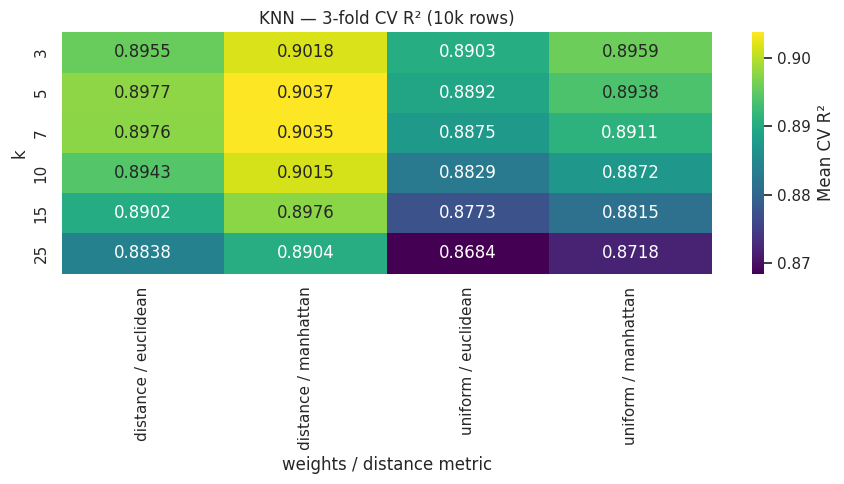

In [22]:
# ---- 3.6 Heatmap of CV R2 (k × weights/metric) ----
cv_res["weights / metric"] = cv_res["param_weights"] + " / " + cv_res["param_p"].map({1: "manhattan", 2: "euclidean"})
heat = cv_res.pivot_table(index="param_n_neighbors", columns="weights / metric", values="mean_test_score")
plt.figure(figsize=(9, 5))
sns.heatmap(heat, annot=True, fmt=".4f", cmap="viridis", cbar_kws={"label": "Mean CV R²"})
plt.title("KNN — 3-fold CV R² (10k rows)")
plt.xlabel("weights / distance metric"); plt.ylabel("k")
plt.tight_layout(); plt.show()

**📝 What this shows:** Manhattan distance works better here, because most of the columns are 0/1 columns from one-hot encoding.

In [23]:
# ---- 3.7 Final tuned KNN (full training set as neighbour pool) & improvement ----
knn_best = KNeighborsRegressor(**best_params, n_jobs=-1).fit(X_train_p, y_train)
start = time.time()
y_pred = knn_best.predict(X_test_p)
print(f"Prediction time for the test set: {time.time() - start:.1f} s")
tuned_scores = regression_metrics(y_test, y_pred)

compare = pd.DataFrame([default_scores, tuned_scores],
                       index=["KNN default (k=5, uniform, euclidean)", f"KNN tuned {best_params}"])
compare.loc["Improvement"] = compare.iloc[1] - compare.iloc[0]
compare.round(4)

Prediction time for the test set: 197.6 s


,R2,RMSE,MAE
"KNN default (k=5, uniform, euclidean)",0.9438,2352.6967,1310.0864
"KNN tuned {'n_neighbors': 5, 'p': 1, 'weights': 'distance'}",0.9492,2238.7573,1265.4934
Improvement,0.0053,-113.9394,-44.5930


In [24]:
# ---- 3.8 5-fold cross-validated R2 (20,000-row training subsample, for speed) ----
cv_idx = stratified_subsample(20000)
cv_scores = cross_val_score(KNeighborsRegressor(**best_params, n_jobs=-1),
                            X_train_p[cv_idx], y_train.values[cv_idx], cv=kf, scoring="r2")
print("CV R2 per fold:", np.round(cv_scores, 4))
print(f"Mean CV R2: {cv_scores.mean():.4f}  (± {cv_scores.std():.4f})")
print("(Lower than the test R2 partly because each fold only has 16k cars to search for neighbours.)")

CV R2 per fold: [0.9264 0.9339 0.9336 0.9303 0.9326]
Mean CV R2: 0.9314  (± 0.0028)
(Lower than the test R2 partly because each fold only has 16k cars to search for neighbours.)


## C4 — Visualisation

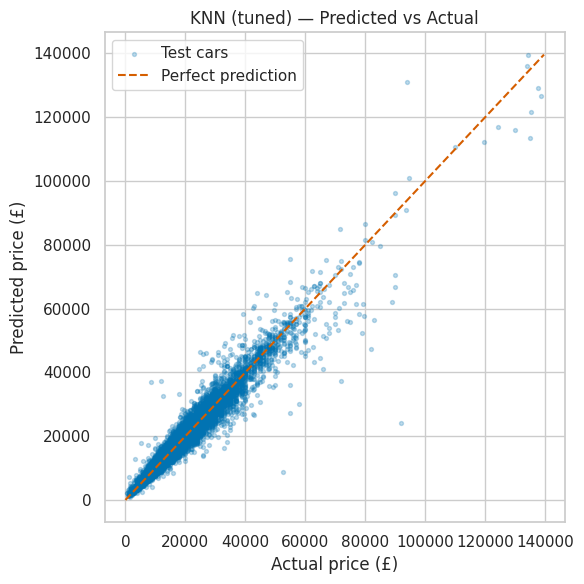

In [25]:
# ---- 3.9 Predicted vs Actual ----
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.25, s=8, label="Test cars")
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.title("KNN (tuned) — Predicted vs Actual")
plt.xlabel("Actual price (£)"); plt.ylabel("Predicted price (£)")
plt.legend(); plt.tight_layout(); plt.show()

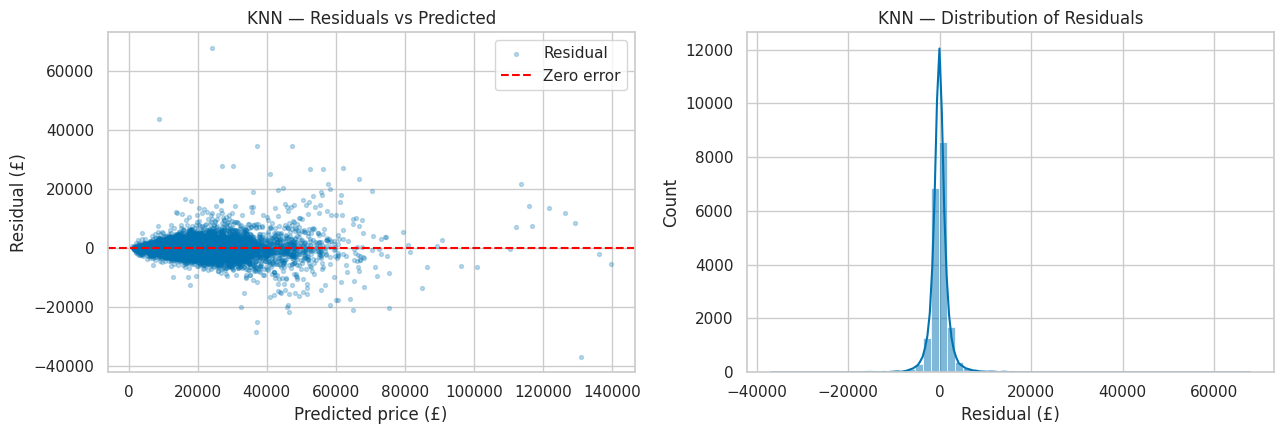

In [26]:
# ---- 3.10 Residual plots ----
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(y_pred, residuals, alpha=0.25, s=8, label="Residual")
axes[0].axhline(0, color="red", linestyle="--", label="Zero error")
axes[0].set_title("KNN — Residuals vs Predicted")
axes[0].set_xlabel("Predicted price (£)"); axes[0].set_ylabel("Residual (£)"); axes[0].legend()

sns.histplot(residuals, bins=60, kde=True, ax=axes[1])
axes[1].set_title("KNN — Distribution of Residuals")
axes[1].set_xlabel("Residual (£)"); axes[1].set_ylabel("Count")
plt.tight_layout(); plt.show()

**📝 What this shows:** Cheap cars are predicted well (£667 off on average) but expensive cars are badly wrong (£5,042 off).

In [27]:
# ---- 3.11 Save KNN results ----
os.makedirs("../results", exist_ok=True)
RESULTS_FILE = "../results/regression_results.csv"
MODEL_NAME = "K-Nearest Neighbors Regressor"

row = pd.DataFrame([{
    "Model": MODEL_NAME,
    **tuned_scores,
    "CV_R2_mean": cv_scores.mean(),
    "Tuned": "Yes (GridSearchCV)",
    "Best_params": str(best_params),
}])
if os.path.exists(RESULTS_FILE):
    old = pd.read_csv(RESULTS_FILE)
    row = pd.concat([old[old["Model"] != MODEL_NAME], row], ignore_index=True)
row.to_csv(RESULTS_FILE, index=False)
print("Saved.")

Saved.


---
# FINAL — Comparison of all 10 regression models (Rubric C2)
All models were trained on the **same preprocessed data** and evaluated on the **same 19,543-car test split**.
Each notebook (01–10) saved its test scores to `../results/regression_results.csv`.

In [28]:
# ============================================================
# FINAL : 10-MODEL REGRESSION COMPARISON TABLE
# ============================================================
EXPECTED = ["Linear Regression", "Ridge Regression", "Lasso Regression", "ElasticNet Regression",
            "Polynomial Regression", "Decision Tree Regressor", "Random Forest Regressor",
            "Gradient Boosting Regressor", "Support Vector Regressor", "K-Nearest Neighbors Regressor"]

results = pd.read_csv(RESULTS_FILE)
missing = [m for m in EXPECTED if m not in results["Model"].values]
if missing:
    print("⚠️ Run these notebooks first, then re-run this cell:", missing)

# ---- F.1 Rank models by R2 (highest first) ----
summary = (results.sort_values("R2", ascending=False)
                  .reset_index(drop=True)
                  .rename(columns={"CV_R2_mean": "5-fold CV R2"}))
summary.index = summary.index + 1
summary.index.name = "Rank"
summary[["Model", "R2", "RMSE", "MAE", "5-fold CV R2", "Tuned", "Best_params"]].style \
    .format({"R2": "{:.4f}", "RMSE": "£{:,.0f}", "MAE": "£{:,.0f}", "5-fold CV R2": "{:.4f}"}) \
    .background_gradient(subset=["R2"], cmap="Greens") \
    .background_gradient(subset=["RMSE", "MAE"], cmap="Reds_r")

,Model,R2,RMSE,MAE,5-fold CV R2,Tuned,Best_params
Rank,,,,,,,
1,Gradient Boosting Regressor,0.9619,"£1,938","£1,114",0.9596,Yes (RandomizedSearchCV),"{'min_samples_leaf': 5, 'max_leaf_nodes': 127, 'learning_rate': 0.05, 'l2_regularization': 1.0, 'n_trees': 616}"
2,Random Forest Regressor,0.9594,"£2,001","£1,163",0.9554,Yes (RandomizedSearchCV),"{'n_estimators': 150, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30}"
3,K-Nearest Neighbors Regressor,0.9492,"£2,239","£1,265",0.9314,Yes (GridSearchCV),"{'n_neighbors': 5, 'p': 1, 'weights': 'distance'}"
4,Decision Tree Regressor,0.9416,"£2,398","£1,361",0.9311,Yes (GridSearchCV),"{'max_depth': 25, 'min_samples_leaf': 3}"
5,Support Vector Regressor,0.9248,"£2,722","£1,370",0.9324,Yes (GridSearchCV),"{'C': 100, 'gamma': 0.01, 'kernel': 'rbf', 'train_rows': 20000}"
6,Polynomial Regression,0.9114,"£2,955","£1,729",0.9151,Yes (GridSearchCV),"{'degree': 3, 'interaction_only': False}"
7,Ridge Regression,0.8581,"£3,740","£2,237",0.8641,Yes (GridSearchCV),"{'alpha': 0.03162, 'solver': 'auto'}"
8,Linear Regression,0.8581,"£3,741","£2,236",0.8641,No (baseline),-
9,Lasso Regression,0.8580,"£3,741","£2,237",0.8641,Yes (GridSearchCV),{'alpha': 0.01}


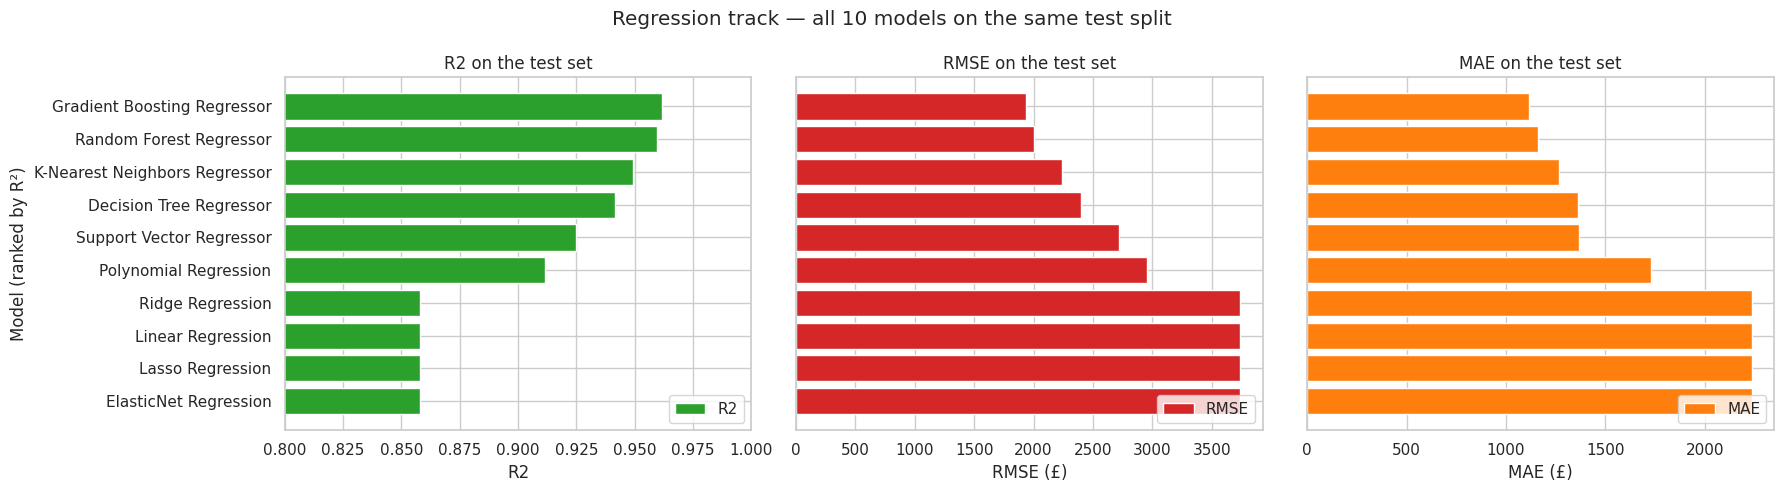

In [29]:
# ---- F.2 Visual comparison of R2, RMSE and MAE ----
plot_df = summary.set_index("Model")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, metric, colour in zip(axes, ["R2", "RMSE", "MAE"], ["tab:green", "tab:red", "tab:orange"]):
    ax.barh(plot_df.index[::-1], plot_df[metric][::-1], color=colour, label=metric)
    ax.set_title(f"{metric} on the test set")
    ax.set_xlabel(metric + (" (£)" if metric != "R2" else ""))
    ax.legend(loc="lower right")
axes[0].set_xlim(0.8, 1.0)
axes[0].set_ylabel("Model (ranked by R²)")
plt.suptitle("Regression track — all 10 models on the same test split")
plt.tight_layout(); plt.show()

Two best-performing models:
                            Model        R2  5-fold CV R2
Rank                                                     
1     Gradient Boosting Regressor  0.961894      0.959598
2         Random Forest Regressor  0.959378      0.955429


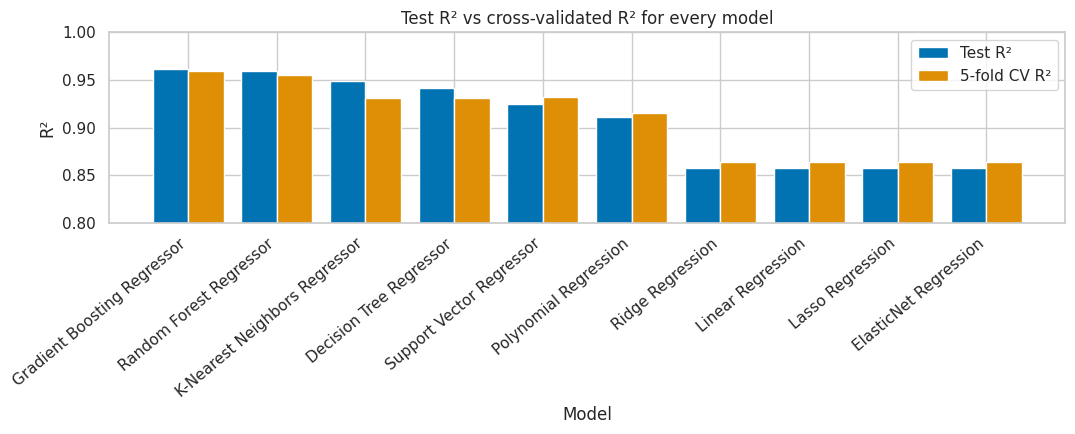

In [30]:
# ---- F.3 The two best models: test R2 vs 5-fold CV R2 ----
top2 = summary.head(2)
print("Two best-performing models:")
print(top2[["Model", "R2", "5-fold CV R2"]].to_string())

x = np.arange(len(summary))
plt.figure(figsize=(11, 4.5))
plt.bar(x - 0.2, summary["R2"], width=0.4, label="Test R²")
plt.bar(x + 0.2, summary["5-fold CV R2"], width=0.4, label="5-fold CV R²")
plt.xticks(x, summary["Model"], rotation=40, ha="right")
plt.ylim(0.8, 1.0)
plt.title("Test R² vs cross-validated R² for every model")
plt.xlabel("Model"); plt.ylabel("R²")
plt.legend(); plt.tight_layout(); plt.show()

## Final conclusion — Regression track

**📝 In short:** Gradient Boosting wins overall at 0.962, followed by Random Forest, while all four linear models are stuck at 0.858.